# 12. Preparacion visible de base anual para determinantes

Flujo activo: `mart_persona` de `revision_4` -> universo anual -> base interpretable -> transformaciones descriptivas -> diagnosticos de preparacion -> exportacion opcional.

Limites: personas adultas con ingreso laboral/de negocio positivo, todas las regiones, montos nominales trimestrales, sin deflactores, sin JKn, sin particiones y sin modelos. La comparabilidad de coeficientes entre anios queda pendiente para una especificacion comun posterior.


## Mapa de secciones requeridas

1. Proposito, universo y limitaciones.
2. Imports y configuracion.
3. Localizacion del proyecto y rutas.
4. Lectura directa del mart.
5. Validacion de columnas y llaves.
6. Seleccion del anio.
7. Restriccion de edad.
8. Validacion del target.
9. Restriccion a ingreso positivo.
10. Tabla del flujo del universo creada en memoria.
11. Definicion visible de variables candidatas, seleccionadas, continuas, categoricas, metadata, pendientes y exclusiones.
12. Diagnostico de faltantes.
13. Reglas explicitas de categorias laborales estructurales.
14. Construccion de la base interpretable.
15. Definicion de categorias de referencia.
16. One-hot encoding k-1.
17. Mapping de variables originales a dummies.
18. Estandarizacion descriptiva de continuas.
19. Resumen del target original y logaritmico.
20. Graficas del target calculadas desde objetos en memoria.
21. Spearman para continuas.
22. Punto biserial para indicadores.
23. Dependencia entre predictores: constantes, duplicados, rango, correlaciones, Cramer's V y VIF.
24. Validaciones finales.
25. Objetos finales disponibles.
26. Exportacion opcional al final.


## 1. Configuracion e imports


In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

ANIO_ANALISIS = 2024
ANIOS_VALIDOS = (2018, 2020, 2022, 2024)
EDAD_MINIMA = 18
TARGET = "ingreso_persona_laboral_negocio_tri"
EXPORTAR_RESULTADOS = True

if ANIO_ANALISIS not in ANIOS_VALIDOS:
    raise ValueError(f"ANIO_ANALISIS debe estar en {ANIOS_VALIDOS}; recibido: {ANIO_ANALISIS}.")
if EDAD_MINIMA <= 0:
    raise ValueError(f"EDAD_MINIMA debe ser positiva; recibida: {EDAD_MINIMA}.")

configuracion_efectiva = pd.DataFrame([
    {"parametro":"ANIO_ANALISIS", "valor":ANIO_ANALISIS},
    {"parametro":"ANIOS_VALIDOS", "valor":ANIOS_VALIDOS},
    {"parametro":"EDAD_MINIMA", "valor":EDAD_MINIMA},
    {"parametro":"TARGET", "valor":TARGET},
    {"parametro":"EXPORTAR_RESULTADOS", "valor":EXPORTAR_RESULTADOS},
])
configuracion_efectiva


,parametro,valor
0,ANIO_ANALISIS,2024
1,ANIOS_VALIDOS,"(2018, 2020, 2022, 2024)"
2,EDAD_MINIMA,18
3,TARGET,ingreso_persona_laboral_negocio_tri
4,EXPORTAR_RESULTADOS,True


## 2. Localizacion del proyecto y rutas por anio


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "README.md").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.preparacion_determinantes import (
    ANIOS_VALIDOS as ANIOS_VALIDOS_MODULO,
    CATEGORICAL_PREDICTORS, CONTINUOUS_PREDICTORS, DIAGNOSTIC_COLS,
    HOUSEHOLD_KEY_COLS, KEY_COLS, LOG_TARGET, METADATA_COLS, PREDICTORS,
    STRUCTURAL_MISSING_LABELS, PreparationConfig, binary_associations,
    build_matrix, build_variable_dictionary, categorical_target_summary,
    category_frequencies, continuous_associations, dependency_versions,
    inspect_year_compatibility_from_source, predictor_dependency_diagnostics,
    prepare_categorical_for_matrix, required_columns, save_processed_outputs,
    standardize_continuous, target_summaries, validate_point_biserial_equivalence,
    validation_checks,
)
if ANIOS_VALIDOS != ANIOS_VALIDOS_MODULO:
    raise ValueError("ANIOS_VALIDOS no coincide con el modulo de preparacion.")

CONFIG = PreparationConfig.from_root(PROJECT_ROOT, year=ANIO_ANALISIS, min_age=EDAD_MINIMA, valid_years=ANIOS_VALIDOS)
INPUT_PATH = CONFIG.input_path
PROCESSED_DIR = CONFIG.processed_dir
TABLE_DIR = CONFIG.table_dir
FIGURE_DIR = CONFIG.figure_dir
TABLE_ROOT = PROJECT_ROOT / "reports" / "tables" / "preparacion_determinantes"

rutas_configuradas = pd.DataFrame([
    {"tipo":"entrada_mart_persona", "ruta":str(INPUT_PATH)},
    {"tipo":"salida_microdatos_fuera_git", "ruta":str(PROCESSED_DIR)},
    {"tipo":"salida_tablas_versionadas", "ruta":str(TABLE_DIR)},
    {"tipo":"salida_figuras_versionadas", "ruta":str(FIGURE_DIR)},
])
rutas_configuradas


,tipo,ruta
0,entrada_mart_persona,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
1,salida_microdatos_fuera_git,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
2,salida_tablas_versionadas,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
3,salida_figuras_versionadas,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...


## 3. Lectura directa del mart


In [3]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"No existe la entrada aprobada: {INPUT_PATH}")
datos_mart = pd.read_csv(INPUT_PATH, low_memory=False)
pd.DataFrame([{"objeto":"datos_mart", "filas":len(datos_mart), "columnas":datos_mart.shape[1], "ruta":str(INPUT_PATH)}])


,objeto,filas,columnas,ruta
0,datos_mart,1203231,140,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...


## 4. Validacion de columnas y llaves


In [4]:
columnas_requeridas = required_columns()
columnas_faltantes = sorted(set(columnas_requeridas) - set(datos_mart.columns))
if columnas_faltantes:
    raise KeyError("Faltan columnas requeridas en el mart: " + ", ".join(columnas_faltantes))

resumen_columnas_llaves = pd.DataFrame([
    {"validacion":"columnas_requeridas_presentes", "valor":len(columnas_requeridas), "estado":"ok"},
    {"validacion":"columnas_totales_mart", "valor":datos_mart.shape[1], "estado":"informativo"},
    {"validacion":"duplicados_llave_persona_mart", "valor":int(datos_mart.duplicated(KEY_COLS).sum()), "estado":"ok" if int(datos_mart.duplicated(KEY_COLS).sum()) == 0 else "revisar"},
    {"validacion":"hogares_unicos_mart", "valor":int(datos_mart[HOUSEHOLD_KEY_COLS].drop_duplicates().shape[0]), "estado":"informativo"},
])
resumen_columnas_llaves


,validacion,valor,estado
0,columnas_requeridas_presentes,38,ok
1,columnas_totales_mart,140,informativo
2,duplicados_llave_persona_mart,0,ok
3,hogares_unicos_mart,345169,informativo


## 5. Filtros visibles: anio, edad, target valido e ingreso positivo


In [5]:
flujo_rows = []
def registrar_paso(paso: str, antes: pd.DataFrame, despues: pd.DataFrame, criterio: str) -> None:
    hogares = int(despues[HOUSEHOLD_KEY_COLS].drop_duplicates().shape[0]) if set(HOUSEHOLD_KEY_COLS).issubset(despues.columns) else math.nan
    flujo_rows.append({"paso":paso, "criterio":criterio, "filas_antes":int(len(antes)), "excluidas":int(len(antes)-len(despues)), "filas_despues":int(len(despues)), "hogares_unicos_despues":hogares})

anio_num = pd.to_numeric(datos_mart["anio"], errors="coerce")
datos_anio = datos_mart.loc[anio_num.eq(ANIO_ANALISIS)].copy()
registrar_paso("anio", datos_mart, datos_anio, f"anio == {ANIO_ANALISIS}")

edad_anio = pd.to_numeric(datos_anio["edad"], errors="coerce")
datos_edad_valida = datos_anio.loc[edad_anio.notna()].copy()
registrar_paso("edad valida", datos_anio, datos_edad_valida, "edad no faltante y numerica")

datos_adultos = datos_edad_valida.loc[pd.to_numeric(datos_edad_valida["edad"], errors="coerce").ge(EDAD_MINIMA)].copy()
registrar_paso("edad minima", datos_edad_valida, datos_adultos, f"edad >= {EDAD_MINIMA}")

target_adultos = pd.to_numeric(datos_adultos[TARGET], errors="coerce")
datos_target_valido = datos_adultos.loc[target_adultos.notna() & np.isfinite(target_adultos)].copy()
registrar_paso("target valido", datos_adultos, datos_target_valido, f"{TARGET} numerico y finito")

universo = datos_target_valido.loc[pd.to_numeric(datos_target_valido[TARGET], errors="coerce").gt(0)].copy()
universo[TARGET] = pd.to_numeric(universo[TARGET], errors="coerce").astype(float)
universo[LOG_TARGET] = np.log(universo[TARGET])
registrar_paso("target positivo", datos_target_valido, universo, f"{TARGET} > 0")
universo = universo.reset_index(drop=True)

flujo_universo = pd.DataFrame(flujo_rows)
display(flujo_universo)
display(universo[["anio", "edad", TARGET, LOG_TARGET]].describe(percentiles=[0.25,0.50,0.75,0.90,0.99]))


,paso,criterio,filas_antes,excluidas,filas_despues,hogares_unicos_despues
0,anio,anio == 2024,1203231,894633,308598,91414
1,edad valida,edad no faltante y numerica,308598,0,308598,91414
2,edad minima,edad >= 18,308598,89770,218828,91389
3,target valido,ingreso_persona_laboral_negocio_tri numerico y...,218828,0,218828,91389
4,target positivo,ingreso_persona_laboral_negocio_tri > 0,218828,77249,141579,80872


,anio,edad,ingreso_persona_laboral_negocio_tri,log_ingreso_persona_laboral_negocio_tri
count,141579.0,141579.000000,1.415790e+05,141579.000000
mean,2024.0,40.975660,3.117187e+04,9.838610
std,0.0,14.374849,6.417135e+04,1.206128
min,2024.0,18.000000,2.930000e+00,1.075002
25%,2024.0,29.000000,1.243344e+04,9.428145
50%,2024.0,40.000000,2.424589e+04,10.096002
75%,2024.0,51.000000,3.822527e+04,10.551252
90%,2024.0,61.000000,5.901638e+04,10.985570
99%,2024.0,76.000000,1.546630e+05,11.949004
max,2024.0,104.000000,1.702174e+07,16.650002


## 6. Variables candidatas, seleccionadas, pendientes y exclusiones


In [6]:
variables_continuas = ["edad", "n_trabajos", "horas_trabajos_total", "tot_integ", "menores", "p65mas"]
variables_categoricas = ["sexo_desc", "nivelaprob_desc", "region_banxico", "tam_loc_desc", "parentesco_desc", "hablaind_desc", "segsoc_desc", "subor_principal_desc", "contrato_principal_desc", "sexo_jefe_desc", "educa_jefe_desc"]
variables_candidatas = variables_continuas + variables_categoricas
variables_seleccionadas = variables_candidatas.copy()
variables_metadata = list(METADATA_COLS)
variables_pendientes = {
    "tam_emp_principal_desc":"Conservar en base interpretable; pendiente por dependencia estructural potencial con subordinacion.",
    "est_socio_desc":"Contexto socioeconomico; pendiente de decision sustantiva antes de entrar a X.",
}
exclusiones_tecnicas = [
    {"grupo":"target_derivados", "criterio":"Excluir target, log(target), componentes y agregados del ingreso objetivo."},
    {"grupo":"identificadores", "criterio":"Excluir llaves de persona/hogar, entidad, municipio e identificadores de X."},
    {"grupo":"pesos_diseno", "criterio":"Conservar factor, factor_hogar, est_dis y upm como metadata; no predictores."},
    {"grupo":"deflactores_reales", "criterio":"No usar deflactores, columnas reales ni JKn."},
]
if variables_continuas != list(CONTINUOUS_PREDICTORS) or variables_categoricas != list(CATEGORICAL_PREDICTORS):
    raise ValueError("Las variables visibles no coinciden con el modulo vigente.")

predictores_iniciales = pd.DataFrame([
    {"variable":v, "tipo":"continua" if v in variables_continuas else "categorica", "estado":"seleccionada_inicial", "transformacion":"sin escalar; matriz diagnostica con OHE si aplica"}
    for v in variables_candidatas
])
display(predictores_iniciales)
display(pd.DataFrame([{"variable":k, "motivo":v} for k, v in variables_pendientes.items()]))
display(pd.DataFrame(exclusiones_tecnicas))


,variable,tipo,estado,transformacion
0,edad,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
1,n_trabajos,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
2,horas_trabajos_total,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
3,tot_integ,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
4,menores,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
5,p65mas,continua,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
6,sexo_desc,categorica,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
7,nivelaprob_desc,categorica,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
8,region_banxico,categorica,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica
9,tam_loc_desc,categorica,seleccionada_inicial,sin escalar; matriz diagnostica con OHE si aplica


,variable,motivo
0,tam_emp_principal_desc,Conservar en base interpretable; pendiente por...
1,est_socio_desc,Contexto socioeconomico; pendiente de decision...


,grupo,criterio
0,target_derivados,"Excluir target, log(target), componentes y agr..."
1,identificadores,"Excluir llaves de persona/hogar, entidad, muni..."
2,pesos_diseno,"Conservar factor, factor_hogar, est_dis y upm ..."
3,deflactores_reales,"No usar deflactores, columnas reales ni JKn."


## 7. Diagnostico de faltantes y reglas laborales estructurales


In [7]:
faltantes_predictores = pd.DataFrame([
    {"variable":v, "tipo":"continua" if v in variables_continuas else "categorica", "faltantes":int(universo[v].isna().sum()), "faltantes_pct":float(universo[v].isna().mean()), "decision":"faltante estructural tratado en matriz" if v in STRUCTURAL_MISSING_LABELS else "usar sin imputacion si no hay faltantes"}
    for v in variables_candidatas
])
reglas_laborales = pd.DataFrame([{"variable":v, "etiqueta_estructural":et, "alcance":"solo matriz diagnostica"} for v, et in STRUCTURAL_MISSING_LABELS.items()])
categorias_preparadas = prepare_categorical_for_matrix(universo)
resumen_laboral = []
for variable in STRUCTURAL_MISSING_LABELS:
    if variable in categorias_preparadas:
        conteos = categorias_preparadas[variable].value_counts(dropna=False).reset_index()
        conteos.columns = ["categoria", "n"]
        conteos.insert(0, "variable", variable)
        resumen_laboral.append(conteos)
resumen_categorias_laborales = pd.concat(resumen_laboral, ignore_index=True) if resumen_laboral else pd.DataFrame()
display(faltantes_predictores.sort_values("faltantes", ascending=False))
display(reglas_laborales)
display(resumen_categorias_laborales.head(30))


,variable,tipo,faltantes,faltantes_pct,decision
14,contrato_principal_desc,categorica,37124,0.262214,faltante estructural tratado en matriz
13,subor_principal_desc,categorica,5205,0.036764,faltante estructural tratado en matriz
0,edad,continua,0,0.000000,usar sin imputacion si no hay faltantes
1,n_trabajos,continua,0,0.000000,usar sin imputacion si no hay faltantes
2,horas_trabajos_total,continua,0,0.000000,usar sin imputacion si no hay faltantes
5,p65mas,continua,0,0.000000,usar sin imputacion si no hay faltantes
6,sexo_desc,categorica,0,0.000000,usar sin imputacion si no hay faltantes
3,tot_integ,continua,0,0.000000,usar sin imputacion si no hay faltantes
4,menores,continua,0,0.000000,usar sin imputacion si no hay faltantes
8,region_banxico,categorica,0,0.000000,usar sin imputacion si no hay faltantes


,variable,etiqueta_estructural,alcance
0,subor_principal_desc,No aplica: sin trabajo principal reportado,solo matriz diagnostica
1,contrato_principal_desc,No aplica: sin contrato principal documentado,solo matriz diagnostica
2,tam_emp_principal_desc,No aplica: sin trabajo principal reportado,solo matriz diagnostica


,variable,categoria,n
0,subor_principal_desc,Sí,104929
1,subor_principal_desc,No,31445
2,subor_principal_desc,No aplica: sin trabajo principal reportado,5205
3,contrato_principal_desc,No,52696
4,contrato_principal_desc,Sí,51759
5,contrato_principal_desc,No aplica: sin contrato principal documentado,37124


## 8. Base interpretable


In [8]:
base_cols = KEY_COLS + [TARGET, LOG_TARGET] + variables_seleccionadas + list(variables_pendientes) + variables_metadata
base_cols = list(dict.fromkeys([c for c in base_cols if c in universo.columns]))
base_determinantes = universo[base_cols].reset_index(drop=True).copy()
validacion_base_interpretable = pd.DataFrame([
    {"validacion":"anio_unico", "valor":sorted(base_determinantes["anio"].dropna().astype(int).unique().tolist()), "estado":"ok" if base_determinantes["anio"].eq(ANIO_ANALISIS).all() else "revisar"},
    {"validacion":"llave_persona_unica", "valor":int(base_determinantes.duplicated(KEY_COLS).sum()), "estado":"ok" if int(base_determinantes.duplicated(KEY_COLS).sum()) == 0 else "revisar"},
    {"validacion":"target_positivo", "valor":float(pd.to_numeric(base_determinantes[TARGET], errors="coerce").min()), "estado":"ok" if pd.to_numeric(base_determinantes[TARGET], errors="coerce").gt(0).all() else "revisar"},
])
display(base_determinantes.head())
display(validacion_base_interpretable)


,anio,folioviv,foliohog,numren,ingreso_persona_laboral_negocio_tri,log_ingreso_persona_laboral_negocio_tri,edad,n_trabajos,horas_trabajos_total,tot_integ,...,tam_emp_principal_desc,est_socio_desc,factor,factor_hogar,est_dis,upm,cve_ent,entidad,cve_mun,municipio
0,2024,100001901,1,1,78789.11,11.274530,32,1.0,48.0,4,...,No sabe,Medio alto,207,207,1,1,1,Aguascalientes,1,Aguascalientes
1,2024,100001901,1,2,31157.59,10.346813,24,1.0,45.0,4,...,De 2 a 5 personas,Medio alto,207,207,1,1,1,Aguascalientes,1,Aguascalientes
2,2024,100001902,1,1,56739.12,10.946219,48,1.0,48.0,4,...,De 501 a más personas,Medio alto,207,207,1,1,1,Aguascalientes,1,Aguascalientes
3,2024,100001902,1,3,29347.82,10.286974,22,1.0,48.0,4,...,De 501 a más personas,Medio alto,207,207,1,1,1,Aguascalientes,1,Aguascalientes
4,2024,100001904,1,1,11861.40,9.381045,60,2.0,30.0,2,...,De 2 a 5 personas,Medio alto,207,207,1,1,1,Aguascalientes,1,Aguascalientes


,validacion,valor,estado
0,anio_unico,[2024],ok
1,llave_persona_unica,0,ok
2,target_positivo,2.93,ok


## 9. Referencias OHE, matriz k-1 y mapping


In [9]:
X, categorias_preparadas, mapping_ohe, referencias_ohe = build_matrix(universo)
y = universo[[TARGET, LOG_TARGET]].reset_index(drop=True).copy()
metadata = universo[METADATA_COLS].reset_index(drop=True).copy()
resumen_matriz = pd.DataFrame([
    {"objeto":"X", "filas":X.shape[0], "columnas":X.shape[1]},
    {"objeto":"y", "filas":y.shape[0], "columnas":y.shape[1]},
    {"objeto":"metadata", "filas":metadata.shape[0], "columnas":metadata.shape[1]},
])
display(referencias_ohe)
display(mapping_ohe.sort_values(["variable_original", "es_referencia", "categoria"]).reset_index(drop=True))
display(resumen_matriz)


,variable,referencia,criterio,n_referencia
0,sexo_desc,Hombre,categoria interpretable definida antes de modelar,82304
1,nivelaprob_desc,Ninguno,categoria interpretable definida antes de modelar,4145
2,region_banxico,Centro,categoria interpretable definida antes de modelar,35628
3,tam_loc_desc,Localidades con 100 000 y más habitantes,categoria interpretable definida antes de modelar,54544
4,parentesco_desc,Jefe(a),categoria interpretable definida antes de modelar,68035
5,hablaind_desc,No,categoria interpretable definida antes de modelar,130582
6,segsoc_desc,No,categoria interpretable definida antes de modelar,58278
7,subor_principal_desc,No,categoria interpretable definida antes de modelar,31445
8,contrato_principal_desc,No,categoria interpretable definida antes de modelar,52696
9,sexo_jefe_desc,Hombre,categoria interpretable definida antes de modelar,100575


,variable_original,categoria,dummy,es_referencia,n,pct,tratamiento_faltante
0,contrato_principal_desc,No aplica: sin contrato principal documentado,contrato_principal_desc__no_aplica_sin_contrat...,False,37124,0.262214,estructural/documentado
1,contrato_principal_desc,Sí,contrato_principal_desc__si,False,51759,0.365584,categoria observada
2,contrato_principal_desc,No,,True,52696,0.372202,categoria observada
3,educa_jefe_desc,Posgrado,educa_jefe_desc__posgrado,False,3037,0.021451,categoria observada
4,educa_jefe_desc,Preescolar,educa_jefe_desc__preescolar,False,34,0.000240,categoria observada
...,...,...,...,...,...,...,...
67,subor_principal_desc,No,,True,31445,0.222102,categoria observada
68,tam_loc_desc,Localidades con 15 000 a 99 999 habitantes,tam_loc_desc__localidades_con_15_000_a_99_999_...,False,16662,0.117687,categoria observada
69,tam_loc_desc,Localidades con 2 500 a 14 999 habitantes,tam_loc_desc__localidades_con_2_500_a_14_999_h...,False,17301,0.122200,categoria observada
70,tam_loc_desc,Localidades con menos de 2 500 habitantes,tam_loc_desc__localidades_con_menos_de_2_500_h...,False,53072,0.374858,categoria observada


,objeto,filas,columnas
0,X,141579,67
1,y,141579,2
2,metadata,141579,12


## 10. Estandarizacion descriptiva de continuas


In [10]:
X_estandarizada_diagnostico, parametros_estandarizacion = standardize_continuous(X)
parametros_estandarizacion


,variable,media,sd_muestral_ddof1,constante,formula
0,edad,40.975660,14.374849,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1
1,n_trabajos,1.055545,0.354949,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1
2,horas_trabajos_total,43.764817,19.820681,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1
3,tot_integ,4.013300,1.892456,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1
4,menores,0.697349,0.959243,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1
5,p65mas,0.259735,0.561329,False,z_i = (x_i - media_x) / s_x; s_x con ddof=1


## 11. Resumen del target original y logaritmico


In [11]:
target_resumen_no_ponderado, target_resumen_ponderado, target_por_region_sexo_escolaridad = target_summaries(universo)
resumen_target_log = universo[LOG_TARGET].describe(percentiles=[0.25,0.50,0.75,0.90,0.99]).rename("valor").reset_index().rename(columns={"index":"metrica"})
resumen_target = {"no_ponderado":target_resumen_no_ponderado, "ponderado":target_resumen_ponderado, "por_region_sexo_escolaridad":target_por_region_sexo_escolaridad, "log_target":resumen_target_log}
display(target_resumen_no_ponderado)
display(target_resumen_ponderado)
display(resumen_target_log)


,metrica,n,media,mediana,desv_std,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max
0,no_ponderado,141579,31171.869715,24245.89,64171.35493,2.93,295.08,1516.3,3815.21,12433.44,24245.89,38225.27,59016.38,79239.13,154663.03,17021739.12


,metrica,n_muestral,suma_factor,media_ponderada,p01,p05,p10,p25,mediana_ponderada,p75,p90,p95,p99,max
0,ponderado_factor_descriptivo,141579,61105085.0,33133.232888,342.39,1770.480857,4402.17,13694.124318,25081.95,39836.04,62853.24,87540.96,169472.548843,17021739.12


,metrica,valor
0,count,141579.000000
1,mean,9.838610
2,std,1.206128
3,min,1.075002
4,25%,9.428145
5,50%,10.096002
6,75%,10.551252
7,90%,10.985570
8,99%,11.949004
9,max,16.650002


## 12. Graficas del target desde memoria


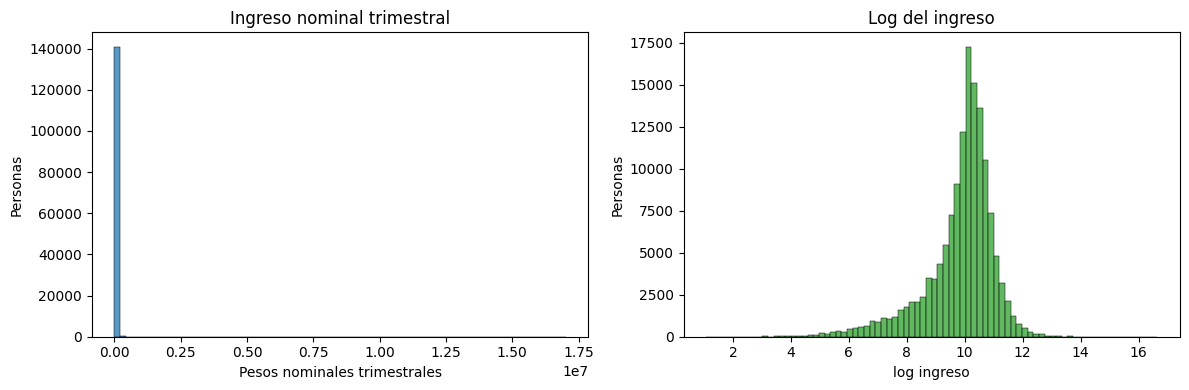

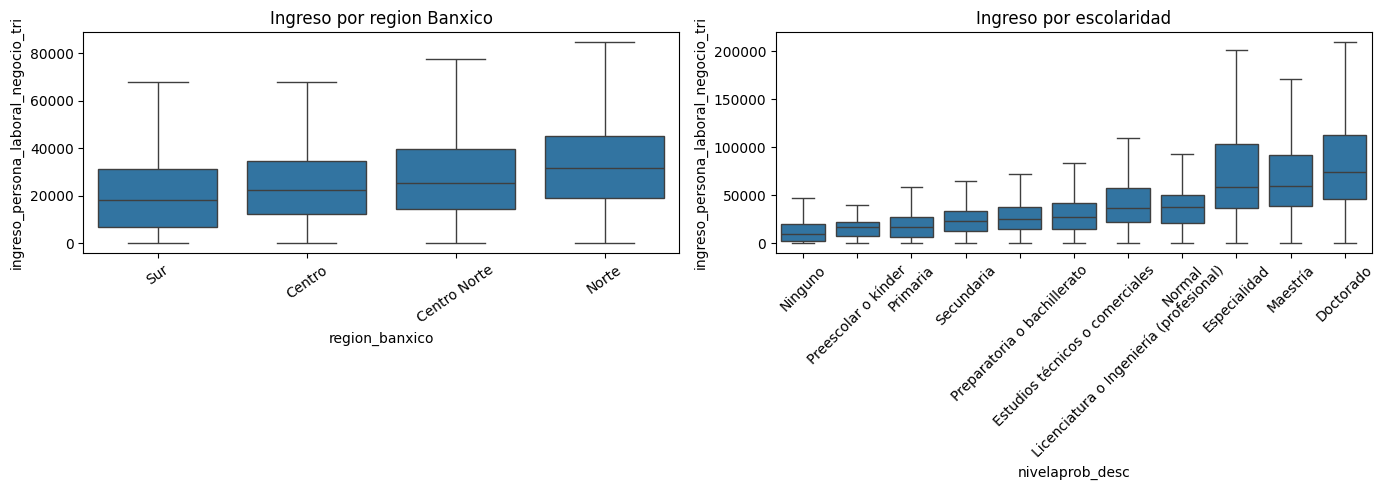

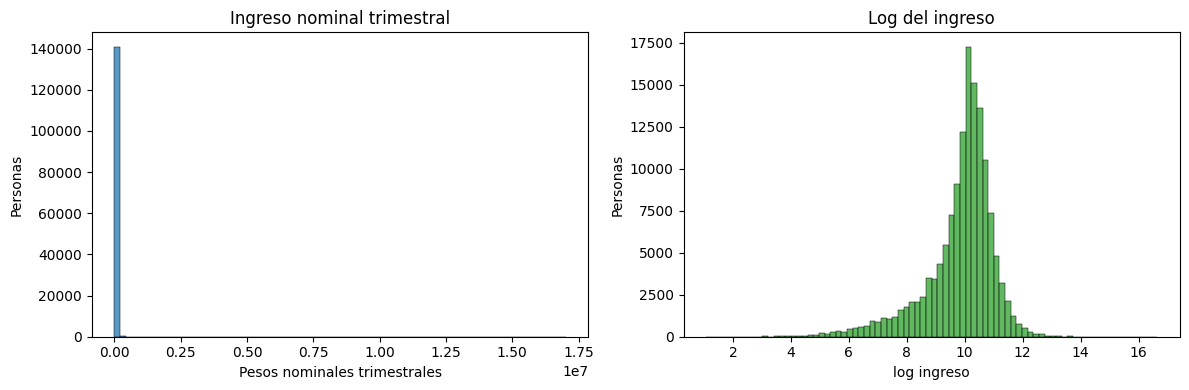

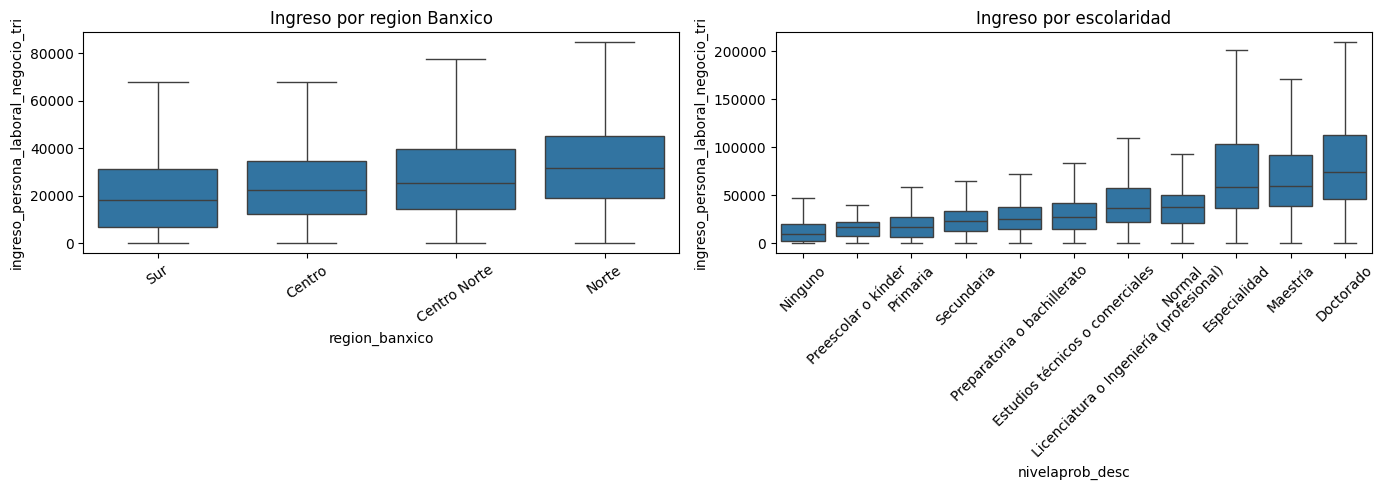

In [12]:
figuras_preparacion = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(universo[TARGET], bins=80, ax=axes[0])
axes[0].set_title("Ingreso nominal trimestral")
axes[0].set_xlabel("Pesos nominales trimestrales")
axes[0].set_ylabel("Personas")
sns.histplot(universo[LOG_TARGET], bins=80, ax=axes[1], color="tab:green")
axes[1].set_title("Log del ingreso")
axes[1].set_xlabel("log ingreso")
axes[1].set_ylabel("Personas")
fig.tight_layout()
figuras_preparacion["target_histogramas"] = fig
display(fig)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden_region = universo.groupby("region_banxico")[TARGET].median().sort_values().index
sns.boxplot(data=universo, x="region_banxico", y=TARGET, order=orden_region, showfliers=False, ax=axes[0])
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Ingreso por region Banxico")
orden_educ = universo.groupby("nivelaprob_desc")[TARGET].median().sort_values().index
sns.boxplot(data=universo, x="nivelaprob_desc", y=TARGET, order=orden_educ, showfliers=False, ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Ingreso por escolaridad")
fig.tight_layout()
figuras_preparacion["target_region_escolaridad"] = fig
display(fig)


## 13. Asociaciones marginales: Spearman y punto biserial


In [17]:
asociaciones_continuas = continuous_associations(universo)
asociaciones_binarias = binary_associations(X, universo, mapping_ohe)
display(asociaciones_continuas.sort_values("spearman_ingreso_original", ascending=False))
display(asociaciones_binarias.sort_values("punto_biserial_ingreso_original", ascending=False).head(20))


,variable,tipo,n_valido,spearman_ingreso_original,nota
2,horas_trabajos_total,continua,141579,0.343412,Correlacion de rangos exploratoria no ponderad...
1,n_trabajos,continua,141579,0.085317,Correlacion de rangos exploratoria no ponderad...
4,menores,continua,141579,-0.007594,Correlacion de rangos exploratoria no ponderad...
0,edad,continua,141579,-0.044600,Correlacion de rangos exploratoria no ponderad...
3,tot_integ,continua,141579,-0.053440,Correlacion de rangos exploratoria no ponderad...
5,p65mas,continua,141579,-0.139393,Correlacion de rangos exploratoria no ponderad...


,dummy,variable_original,categoria_vs_resto,n_valido,frecuencia_1,frecuencia_0,media_target_1,media_target_0,punto_biserial_ingreso_original,punto_biserial_log_target,nota
49,contrato_principal_desc__si,contrato_principal_desc,Sí,141579,51759,89820,44302.221303,23605.471721,0.155326,0.422053,Pearson entre indicador 0/1 y target; compara ...
45,segsoc_desc__si,segsoc_desc,Sí,141579,83301,58278,38549.570099,20626.383945,0.137453,0.382755,Pearson entre indicador 0/1 y target; compara ...
57,educa_jefe_desc__profesional_completa,educa_jefe_desc,Profesional completa,141579,15615,125964,55405.039248,28167.829336,0.132959,0.190243,Pearson entre indicador 0/1 y target; compara ...
4,nivelaprob_desc__licenciatura_o_ingenieria_pro...,nivelaprob_desc,Licenciatura o Ingeniería (profesional),141579,27905,113674,47317.731014,27208.340152,0.124661,0.206461,Pearson entre indicador 0/1 y target; compara ...
51,educa_jefe_desc__posgrado,educa_jefe_desc,Posgrado,141579,3037,138542,74477.574198,30222.558860,0.099916,0.118770,Pearson entre indicador 0/1 y target; compara ...
5,nivelaprob_desc__maestria,nivelaprob_desc,Maestría,141579,2243,139336,76960.851926,30434.768843,0.090532,0.115079,Pearson entre indicador 0/1 y target; compara ...
12,region_banxico__norte,region_banxico,Norte,141579,32110,109469,39361.463751,28769.656627,0.069119,0.139204,Pearson entre indicador 0/1 y target; compara ...
47,subor_principal_desc__si,subor_principal_desc,Sí,141579,104929,36650,33469.566794,24593.559844,0.060585,0.387874,Pearson entre indicador 0/1 y target; compara ...
1,nivelaprob_desc__doctorado,nivelaprob_desc,Doctorado,141579,417,141162,89350.468345,31000.007063,0.049276,0.057689,Pearson entre indicador 0/1 y target; compara ...
2,nivelaprob_desc__especialidad,nivelaprob_desc,Especialidad,141579,360,141219,85087.234778,31034.426939,0.042421,0.046822,Pearson entre indicador 0/1 y target; compara ...


## 14. Dependencia entre predictores


In [18]:
diagnosticos_dependencia = predictor_dependency_diagnostics(X, categorias_preparadas)
display(diagnosticos_dependencia["rango_matriz"])
display(diagnosticos_dependencia["constantes"])
display(diagnosticos_dependencia["duplicadas"])
display(diagnosticos_dependencia["correlaciones_continuas"].head(15))
display(diagnosticos_dependencia["asociacion_categoricas_cramers_v"].head(20))
display(diagnosticos_dependencia["vif"].head(20))


,filas,columnas_X,columnas_con_intercepto,rango_con_intercepto,deficiencia_rango,estado
0,141579,67,68,68,0,rango_completo


,columna,valores_unicos


,columna_a,columna_b


,variable_a,variable_b,pearson
0,edad,n_trabajos,0.054898
1,edad,horas_trabajos_total,-0.051649
2,edad,tot_integ,-0.221576
3,edad,menores,-0.212211
4,edad,p65mas,0.305702
5,n_trabajos,horas_trabajos_total,0.402380
6,n_trabajos,tot_integ,-0.013760
7,n_trabajos,menores,0.016182
8,n_trabajos,p65mas,-0.016894
9,horas_trabajos_total,tot_integ,0.022417


,variable_a,variable_b,cramers_v,nota
0,sexo_desc,nivelaprob_desc,0.100603,Asociacion descriptiva entre categoricas; sin ...
1,sexo_desc,region_banxico,0.027744,Asociacion descriptiva entre categoricas; sin ...
2,sexo_desc,tam_loc_desc,0.060921,Asociacion descriptiva entre categoricas; sin ...
3,sexo_desc,parentesco_desc,0.430775,Asociacion descriptiva entre categoricas; sin ...
4,sexo_desc,hablaind_desc,0.020814,Asociacion descriptiva entre categoricas; sin ...
5,sexo_desc,segsoc_desc,0.077173,Asociacion descriptiva entre categoricas; sin ...
6,sexo_desc,subor_principal_desc,0.095658,Asociacion descriptiva entre categoricas; sin ...
7,sexo_desc,contrato_principal_desc,0.087279,Asociacion descriptiva entre categoricas; sin ...
8,sexo_desc,sexo_jefe_desc,0.262545,Asociacion descriptiva entre categoricas; sin ...
9,sexo_desc,educa_jefe_desc,0.039532,Asociacion descriptiva entre categoricas; sin ...


,columna,vif,estado,nota
0,contrato_principal_desc__no_aplica_sin_contrat...,36.498696,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
1,subor_principal_desc__si,36.389057,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
2,nivelaprob_desc__secundaria,12.597583,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
3,nivelaprob_desc__preparatoria_o_bachillerato,11.835690,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
4,nivelaprob_desc__licenciatura_o_ingenieria_pro...,11.778720,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
5,nivelaprob_desc__primaria,9.158746,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
6,educa_jefe_desc__secundaria_completa,7.900243,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
7,educa_jefe_desc__preparatoria_completa,5.803012,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
8,educa_jefe_desc__profesional_completa,5.533421,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...
9,educa_jefe_desc__primaria_completa,5.174074,ok,VIF_j = 1/(1-R_j^2). En dummies depende de la ...


## 15. Compatibilidad anual inspeccionada


In [19]:
compatibilidad_anual = inspect_year_compatibility_from_source(datos_mart, CONFIG, write_outputs=False)
for nombre, tabla in compatibilidad_anual.items():
    print(nombre, tabla.shape)
    display(tabla.head(20))


compatibilidad_anios (4, 11)


,anio,estado,filas_anio,filas_universo,hogares_unicos,columnas_requeridas_faltantes,referencias_ohe_faltantes,anio_base_comparacion,categorias_nuevas_vs_anio_base,categorias_ausentes_vs_anio_base,nota
0,2018,compatible_para_generar_base,269206,120054,67807,,,2024,5,9,Inspeccion de esquema; no genera matrices ni b...
1,2020,revisar_antes_de_generar_base,315743,139394,79365,,segsoc_desc,2024,7,10,Inspeccion de esquema; no genera matrices ni b...
2,2022,revisar_antes_de_generar_base,309684,141514,80217,,segsoc_desc,2024,5,8,Inspeccion de esquema; no genera matrices ni b...
3,2024,compatible_para_generar_base,308598,141579,80872,,,2024,0,0,Inspeccion de esquema; no genera matrices ni b...


compatibilidad_columnas (152, 3)


,anio,columna,presente
0,2018,anio,True
1,2018,folioviv,True
2,2018,foliohog,True
3,2018,numren,True
4,2018,ingreso_persona_laboral_negocio_tri,True
5,2018,factor,True
6,2018,factor_hogar,True
7,2018,est_dis,True
8,2018,upm,True
9,2018,cve_ent,True


compatibilidad_categorias_ohe (44, 11)


,anio,variable,referencia_prevista,referencia_encontrada,referencia_presente,n_referencia,categorias_observadas,anio_base_comparacion,categorias_nuevas_vs_anio_base,categorias_ausentes_vs_anio_base,error
0,2018,sexo_desc,Hombre,Hombre,True,71734,2,2024,,,
1,2018,nivelaprob_desc,Ninguno,Ninguno,True,4833,10,2024,Carrera técnica o comercial; Preescolar; Profe...,Especialidad; Estudios técnicos o comerciales;...,
2,2018,region_banxico,Centro,Centro,True,30762,4,2024,,,
3,2018,tam_loc_desc,prefijo: Localidades con 100 000,Localidades con 100 000 y más habitantes,True,43910,4,2024,,,
4,2018,parentesco_desc,Jefe(a),Jefe(a),True,58573,25,2024,Primo(a); Sobrino(a) .9102 nóicpircseD .8102 y,Bisabuelo(a); Hijo(a) de crianza; Medio(a) her...,
5,2018,hablaind_desc,No,No,True,110980,2,2024,,,
6,2018,segsoc_desc,No,No,True,51429,2,2024,,,
7,2018,subor_principal_desc,No,No,True,26726,3,2024,,,
8,2018,contrato_principal_desc,No,No,True,47620,3,2024,,,
9,2018,sexo_jefe_desc,Hombre,Hombre,True,91216,2,2024,,,


## 16. Validaciones finales


In [20]:
diccionario_variables = build_variable_dictionary(datos_mart, universo, CONFIG)
validacion_punto_biserial = validate_point_biserial_equivalence()
validaciones_preparacion = validation_checks(datos_mart, universo, X, X_estandarizada_diagnostico, y, metadata, mapping_ohe, diccionario_variables, validacion_punto_biserial, CONFIG)
validaciones_base = pd.DataFrame([
    {"validacion":"base_interpretable_anio_unico", "resultado":"ok" if base_determinantes["anio"].eq(ANIO_ANALISIS).all() else "revisar", "detalle":f"Anios: {sorted(base_determinantes['anio'].dropna().astype(int).unique().tolist())}"},
    {"validacion":"base_interpretable_target_positivo", "resultado":"ok" if pd.to_numeric(base_determinantes[TARGET], errors="coerce").gt(0).all() else "revisar", "detalle":"Todas las filas deben tener target positivo."},
    {"validacion":"base_interpretable_llave_unica", "resultado":"ok" if int(base_determinantes.duplicated(KEY_COLS).sum()) == 0 else "revisar", "detalle":f"Duplicados: {int(base_determinantes.duplicated(KEY_COLS).sum())}."},
])
validaciones = pd.concat([validaciones_preparacion, validacion_punto_biserial, validaciones_base], ignore_index=True, sort=False)
validaciones


,validacion,resultado,detalle,valor_scipy,valor_pearson,diferencia_abs,tolerancia
0,universo_anio_edad_target,ok,"Todas las filas finales cumplen anio 2024, eda...",NaN,NaN,NaN,NaN
1,salidas_universo_anio_unico,ok,Anios presentes en universo/base interpretable...,NaN,NaN,NaN,NaN
2,llave_persona_unica,ok,"Duplicados ['anio', 'folioviv', 'foliohog', 'n...",NaN,NaN,NaN,NaN
3,filas_X_y_metadata,ok,"Dimensiones: X=(141579, 67), X_scaled=(141579,...",NaN,NaN,NaN,NaN
4,sin_target_derivados_metadata_en_X,ok,Columnas prohibidas en X: ninguna,NaN,NaN,NaN,NaN
5,ohe_referencias_consistentes,ok,Cada variable categorica tiene exactamente una...,NaN,NaN,NaN,NaN
6,X_sin_infinitos,ok,Valores no finitos en X: 0.,NaN,NaN,NaN,NaN
7,continuas_sin_imputacion_necesaria,ok,Faltantes en continuas seleccionadas: 0.,NaN,NaN,NaN,NaN
8,pendientes_fuera_de_X,ok,Pendientes dentro de predictores: ninguno,NaN,NaN,NaN,NaN
9,punto_biserial_pearson_toy,ok,Diferencia absoluta toy: 2.220446049250313e-16.,NaN,NaN,NaN,NaN


## 17. Objetos finales en memoria


In [21]:
objetos_finales = pd.DataFrame([
    {"objeto":"datos_mart", "tipo":type(datos_mart).__name__, "filas":len(datos_mart), "columnas":datos_mart.shape[1]},
    {"objeto":"universo", "tipo":type(universo).__name__, "filas":len(universo), "columnas":universo.shape[1]},
    {"objeto":"flujo_universo", "tipo":type(flujo_universo).__name__, "filas":len(flujo_universo), "columnas":flujo_universo.shape[1]},
    {"objeto":"base_determinantes", "tipo":type(base_determinantes).__name__, "filas":len(base_determinantes), "columnas":base_determinantes.shape[1]},
    {"objeto":"X", "tipo":type(X).__name__, "filas":X.shape[0], "columnas":X.shape[1]},
    {"objeto":"X_estandarizada_diagnostico", "tipo":type(X_estandarizada_diagnostico).__name__, "filas":X_estandarizada_diagnostico.shape[0], "columnas":X_estandarizada_diagnostico.shape[1]},
    {"objeto":"y", "tipo":type(y).__name__, "filas":y.shape[0], "columnas":y.shape[1]},
    {"objeto":"metadata", "tipo":type(metadata).__name__, "filas":metadata.shape[0], "columnas":metadata.shape[1]},
    {"objeto":"mapping_ohe", "tipo":type(mapping_ohe).__name__, "filas":mapping_ohe.shape[0], "columnas":mapping_ohe.shape[1]},
    {"objeto":"referencias_ohe", "tipo":type(referencias_ohe).__name__, "filas":referencias_ohe.shape[0], "columnas":referencias_ohe.shape[1]},
    {"objeto":"parametros_estandarizacion", "tipo":type(parametros_estandarizacion).__name__, "filas":parametros_estandarizacion.shape[0], "columnas":parametros_estandarizacion.shape[1]},
    {"objeto":"resumen_target", "tipo":type(resumen_target).__name__, "filas":len(resumen_target), "columnas":"diccionario"},
    {"objeto":"asociaciones_continuas", "tipo":type(asociaciones_continuas).__name__, "filas":len(asociaciones_continuas), "columnas":asociaciones_continuas.shape[1]},
    {"objeto":"asociaciones_binarias", "tipo":type(asociaciones_binarias).__name__, "filas":len(asociaciones_binarias), "columnas":asociaciones_binarias.shape[1]},
    {"objeto":"diagnosticos_dependencia", "tipo":type(diagnosticos_dependencia).__name__, "filas":len(diagnosticos_dependencia), "columnas":"diccionario"},
    {"objeto":"validaciones", "tipo":type(validaciones).__name__, "filas":len(validaciones), "columnas":validaciones.shape[1]},
])
objetos_finales


,objeto,tipo,filas,columnas
0,datos_mart,DataFrame,1203231,140
1,universo,DataFrame,141579,141
2,flujo_universo,DataFrame,5,6
3,base_determinantes,DataFrame,141579,33
4,X,DataFrame,141579,67
5,X_estandarizada_diagnostico,DataFrame,141579,67
6,y,DataFrame,141579,2
7,metadata,DataFrame,141579,12
8,mapping_ohe,DataFrame,72,7
9,referencias_ohe,DataFrame,11,4


## 18. Exportacion opcional final


In [22]:
if EXPORTAR_RESULTADOS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    processed_paths = save_processed_outputs(CONFIG, universo, X, X_estandarizada_diagnostico, y, metadata, predictores_iniciales, parametros_estandarizacion, mapping_ohe, referencias_ohe)
    tablas_preparacion = {
        "flujo_universo":flujo_universo,
        "diccionario_variables":diccionario_variables,
        "exclusiones_variables":diccionario_variables.loc[~diccionario_variables["papel"].eq("predictor candidato")].copy(),
        "faltantes_predictores":faltantes_predictores,
        "categorias_frecuencias":category_frequencies(categorias_preparadas),
        "categorias_target_resumen":categorical_target_summary(universo, categorias_preparadas),
        "referencias_ohe":referencias_ohe,
        "mapping_ohe":mapping_ohe,
        "target_resumen_no_ponderado":target_resumen_no_ponderado,
        "target_resumen_ponderado":target_resumen_ponderado,
        "target_por_region_sexo_escolaridad":target_por_region_sexo_escolaridad,
        "correlaciones_continuas_spearman":asociaciones_continuas,
        "correlaciones_dummies_punto_biserial":asociaciones_binarias,
        "dependencia_constantes":diagnosticos_dependencia["constantes"],
        "dependencia_duplicadas":diagnosticos_dependencia["duplicadas"],
        "dependencia_continuas_pearson":diagnosticos_dependencia["correlaciones_continuas"],
        "dependencia_categoricas_cramers_v":diagnosticos_dependencia["asociacion_categoricas_cramers_v"],
        "dependencia_rango_matriz":diagnosticos_dependencia["rango_matriz"],
        "dependencia_vif":diagnosticos_dependencia["vif"],
        "validaciones_preparacion":validaciones,
        "predictores_iniciales":predictores_iniciales,
        "parametros_estandarizacion":parametros_estandarizacion,
    }
    for nombre, tabla in tablas_preparacion.items():
        tabla.to_csv(TABLE_DIR / f"{nombre}.csv", index=False, encoding="utf-8")
    for nombre, tabla in compatibilidad_anual.items():
        tabla.to_csv(TABLE_ROOT / f"{nombre}.csv", index=False, encoding="utf-8")
    figuras_generadas = []
    for nombre, figura in figuras_preparacion.items():
        ruta = FIGURE_DIR / f"{nombre}.png"
        figura.savefig(ruta, dpi=160, bbox_inches="tight")
        figuras_generadas.append({"figura":nombre, "archivo":str(ruta), "origen":"objeto_en_memoria"})
        plt.close(figura)
    figuras_generadas_df = pd.DataFrame(figuras_generadas)
    figuras_generadas_df.to_csv(TABLE_DIR / "figuras_generadas.csv", index=False, encoding="utf-8")
    manifest_preparacion = {
        "etapa":12,
        "nombre":f"preparacion_base_determinantes_{ANIO_ANALISIS}",
        "estado":"pendiente_ejecucion_manual",
        "codigo_refactorizado_por_codex":True,
        "codex_ejecuto_notebook":False,
        "notebook_ejecutado":False,
        "configuracion":configuracion_efectiva.to_dict(orient="records"),
        "entrada":str(INPUT_PATH),
        "salidas_fuera_de_git":processed_paths,
        "salidas_tablas":{n:str(TABLE_DIR / f"{n}.csv") for n in tablas_preparacion},
        "salidas_figuras":figuras_generadas_df.to_dict(orient="records"),
        "salidas_compatibilidad":{n:str(TABLE_ROOT / f"{n}.csv") for n in compatibilidad_anual},
        "versiones":dependency_versions(),
        "conteos":{"filas_mart":int(len(datos_mart)), "filas_universo":int(len(universo)), "hogares_universo":int(universo[HOUSEHOLD_KEY_COLS].drop_duplicates().shape[0]), "columnas_X":int(X.shape[1])},
        "variables_continuas":variables_continuas,
        "variables_categoricas":variables_categoricas,
        "variables_pendientes":variables_pendientes,
        "referencias_ohe":referencias_ohe.to_dict(orient="records"),
        "parametros_estandarizacion":parametros_estandarizacion.to_dict(orient="records"),
        "validaciones":validaciones.to_dict(orient="records"),
        "limitaciones":["Montos nominales trimestrales.", "Sin deflactores, sin JKn, sin particiones y sin modelos.", "Comparabilidad de coeficientes pendiente de especificacion comun posterior."],
    }
    (TABLE_DIR / "manifest_preparacion_determinantes.json").write_text(json.dumps(manifest_preparacion, ensure_ascii=False, indent=2), encoding="utf-8")
else:
    processed_paths = {}
    figuras_generadas_df = pd.DataFrame(columns=["figura", "archivo", "origen"])
    manifest_preparacion = {"estado":"no_exportado", "motivo":"EXPORTAR_RESULTADOS=False"}

pd.DataFrame([
    {"elemento":"exportacion", "estado":"realizada" if EXPORTAR_RESULTADOS else "omitida"},
    {"elemento":"manifest", "estado":manifest_preparacion["estado"]},
    {"elemento":"base_interpretable", "ruta":processed_paths.get("base_interpretable", "no exportada")},
])


,elemento,estado,ruta
0,exportacion,realizada,NaN
1,manifest,pendiente_ejecucion_manual,NaN
2,base_interpretable,NaN,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...
